# 04 - Perceptron

The weakest linear baseline in the lineup. We keep it in
the project as a sanity-check floor that the more
sophisticated models can be measured against. It gets
close to its Bayes-error rate and then just plateaus.

## 1 - Setup

Here we set matplotlib to inline mode, add the project root
to sys.path so we can import from src/, and bring in the
shared helpers together with the project-wide RANDOM_STATE = 42
(bound once in src/_constants.py, re-exported via src).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# notebooks/ sits one level under the project root, so we add
# the project root to make `from src import ...` work.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import (
    RANDOM_STATE,
    DATASETS,
    load_preprocessed,
    fit_and_score,
    build_metrics_payload,
    save_metrics,
    save_predictions,
    save_test_index,
    save_figure,
    confusion_matrix_figure,
    roc_curve_figure,
    print_dataset_block,
    print_delta,
    model_results_dir,
)

print(f"RANDOM_STATE = {RANDOM_STATE} (bound once in src/_constants.py)")

RANDOM_STATE = 42 (bound once in src/_constants.py)


## 2 - Load the preprocessed feature matrices

load_preprocessed() gives us back the two matrices that we
made in Phase 1: the Baseline (just nutrition + tags) and
the Advanced (the Baseline plus 9 engineered culinary
features). They share the same train/test split so the A/B
comparison is fair.

In [2]:
datasets, y_train, y_test = load_preprocessed()

print(f"Baseline X_train: {datasets['Baseline'][0].shape}")
print(f"Advanced X_train: {datasets['Advanced'][0].shape}")
print(f"y_test class balance: Miss={int((y_test == 0).sum())} / "
      f"Hit={int((y_test == 1).sum())} "
      f"(majority-class rate: {max(y_test.mean(), 1 - y_test.mean()):.4f})")

Baseline X_train: (14578, 678)
Advanced X_train: (14578, 687)
y_test class balance: Miss=1698 / Hit=1947 (majority-class rate: 0.5342)


## 3 - Configure the model

Default Perceptron with random_state=RANDOM_STATE for the
SGD shuffle, max_iter=1000 and tol=1e-3 - these match the
sklearn defaults.

In [3]:
from sklearn.linear_model import Perceptron

MODEL_SLUG    = "perceptron"
MODEL_NAME    = "Perceptron"
DISPLAY_NAME  = "Perceptron"

MODEL_CONFIG = {
    "max_iter":     1000,
    "tol":          1e-3,
    "random_state": RANDOM_STATE,
}
MODEL_CONFIG

{'max_iter': 1000, 'tol': 0.001, 'random_state': 42}

## 4 - Train on both matrices

For each matrix we build a fresh model from scratch (the
factory below gets called once per dataset). Nothing leaks
from Baseline to Advanced so the delta we see is really
only because of the 9 engineered features.

In [4]:
def _build_model():
    return Perceptron(**MODEL_CONFIG)

per_ds_results = {}
for ds_name in DATASETS:
    X_train, X_test = datasets[ds_name]
    model = _build_model()
    result = fit_and_score(model, X_train, y_train, X_test, y_test)
    per_ds_results[ds_name] = result

    print_dataset_block(ds_name, X_train.shape, result)
    save_predictions(MODEL_SLUG, ds_name, result["y_pred"])

print_delta(per_ds_results)
save_test_index(MODEL_SLUG, y_test)


  --- Baseline  (X_train: (14578, 678)) ---
     Test Accuracy : 0.5495
     Test F1-Score : 0.5726
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          903       795   FP rate = 0.4682
        True:Hit           847      1100   FN rate = 0.4350

  --- Advanced  (X_train: (14578, 687)) ---
     Test Accuracy : 0.5435
     Test F1-Score : 0.5667
     Confusion Matrix:
                       Pred:Miss  Pred:Hit
        True:Miss          893       805   FP rate = 0.4741
        True:Hit           859      1088   FN rate = 0.4412

  >> Δ (Advanced − Baseline):  Acc -0.0060  |  F1 -0.0060


PosixPath('/Users/itaysegev/Final_Project_ML/results/perceptron/test_index.npy')

## 5 - Confusion matrix (Advanced fit)

An annotated heatmap of the confusion matrix from the
Advanced fit. We render it inline and also save it to
results/<slug>/confusion_matrix.png.

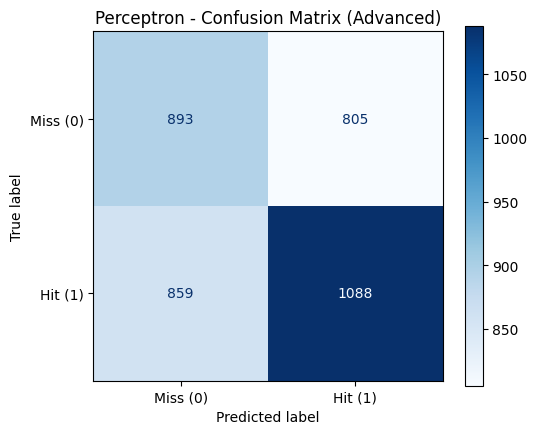

In [5]:
adv = per_ds_results["Advanced"]
cm_array = np.array([
    [adv["confusion_matrix"]["tn"], adv["confusion_matrix"]["fp"]],
    [adv["confusion_matrix"]["fn"], adv["confusion_matrix"]["tp"]],
])
fig_cm = confusion_matrix_figure(
    cm_array,
    title=f"{DISPLAY_NAME} - Confusion Matrix (Advanced)",
)
save_figure(MODEL_SLUG, "confusion_matrix.png", fig_cm)
plt.show()

## 6 - ROC curve + AUC (Advanced fit)

We use predict_proba (or decision_function if the model
doesn't have probabilities). The AUC tells us how well the
model ranks the positives over the negatives, regardless of
the threshold we pick. Phase 4's threshold sweep is built
on top of this.

Test ROC AUC (Advanced): 0.5640


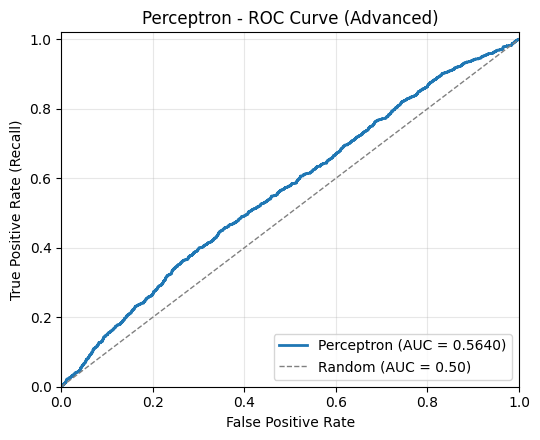

In [6]:
fig_roc, auc = roc_curve_figure(
    y_test, adv["proba_hit"],
    title=f"{DISPLAY_NAME} - ROC Curve (Advanced)",
    model_label=DISPLAY_NAME,
)
save_figure(MODEL_SLUG, "roc_curve.png", fig_roc)
print(f"Test ROC AUC (Advanced): {auc:.4f}")
plt.show()

## 8 - Persist the canonical metrics JSON

One JSON per model, written into
results/<slug>/metrics.json. The schema is defined in
src.train_utils.build_metrics_payload, and the master
comparison notebook reads from those files.

In [7]:
extras = {"roc_auc_advanced": auc}

payload = build_metrics_payload(
    model_name=MODEL_NAME,
    display_name=DISPLAY_NAME,
    model_config=MODEL_CONFIG,
    n_train=len(y_train),
    n_test=len(y_test),
    random_state=RANDOM_STATE,
    per_dataset_results=per_ds_results,
    extras=extras,
)
metrics_path = save_metrics(MODEL_SLUG, payload)
print(f"Wrote {metrics_path.relative_to(metrics_path.parent.parent.parent)}")

Wrote results/perceptron/metrics.json


## 9 - Summary

    **Model:** Perceptron

    - **Test Accuracy / F1:** about 0.5435 / 0.5667 - the weakest
  model in the lineup, and the only one that loses accuracy
  from the engineered features.
- **Errors are pretty symmetric** (FP is about FN), the
  opposite of AdaBoost which is very asymmetric.

    To see this model side by side with the other six, run the
    master comparison notebook (`08_Master_Comparison.ipynb`).